In [85]:
import json
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas
import seaborn as sns

from normalize import (
    agglomerative_cluster_tags,
    assign_canonical_publishers,
    assign_canonical_tags_per_cluster,
    canonicalize_tag_group,
    cluster_tags_with_umap_hdbscan,
    compute_keyword_counts,
    cosine_distance,
    evaluate_agglomerative_cluster_counts,
    fuzzy_group_publishers,
    generate_tag_embeddings,
    get_keywords_by_pdf_hash,
    get_tag_embedding,
    normalize_publisher,
    normalize_tag,
    plot_keyword_occurrences,
    plot_tsne_clusters,
)


In [ ]:
def compute_keyword_counts(df: pd.DataFrame) -> pd.DataFrame:
    exploded = (
        df[["pdf_hash", "keywords"]]
        .explode("keywords")
        .dropna(subset=["keywords"])
    )
    exploded["keywords"] = (
        exploded["keywords"].map(
            lambda value: value.strip().lower() if isinstance(value, str) else None
        )
    )
    exploded = exploded.dropna(subset=["keywords"])
    exploded = exploded[exploded["keywords"] != ""]

    if exploded.empty:
        raise ValueError("No keywords available to count.")

    return (
        exploded.groupby("keywords")["pdf_hash"]
        .nunique()
        .reset_index(name="pdf_count")
        .sort_values("pdf_count", ascending=False)
    )


def plot_keyword_occurrences(counts: pd.DataFrame) -> None:
    if counts.empty or not {"keywords", "pdf_count"}.issubset(counts.columns):
        raise ValueError("counts DataFrame must have 'keywords' and 'pdf_count'.")
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=counts,
        x="keywords",
        y="pdf_count",
        color="#4C78A8",
    )
    ax.set_xlabel("Keyword")
    ax.set_ylabel("Number of PDFs")
    ax.set_title("Keyword Occurrences Across PDFs")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()



def evaluate_agglomerative_cluster_counts(
    embeddings_df: pd.DataFrame,
    cluster_counts: Iterable[int],
    *,
    linkage: str = "average",
    metric: str = "cosine",
    workers: int = 4,
) -> pd.DataFrame:
    required = {"tag", "embedding"}
    if embeddings_df.empty or not required.issubset(embeddings_df.columns):
        raise ValueError("embeddings_df must contain 'tag' and 'embedding'.")

    vectors = embeddings_df["embedding"].to_list()
    if not vectors:
        raise ValueError("No embeddings available.")
    matrix = np.vstack([np.asarray(vec, dtype=float).ravel() for vec in vectors])
    workers = max(1, workers)

    def _score(n_clusters: int) -> dict[str, float] | None:
        if n_clusters < 2:
            return None
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            metric=metric,
        )
        labels = model.fit_predict(matrix)
        if len(np.unique(labels)) < 2:
            return None
        score = silhouette_score(matrix, labels, metric=metric)
        return {"n_clusters": n_clusters, "silhouette_score": score}

    rows: list[dict[str, float]] = []
    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = {executor.submit(_score, count): count for count in cluster_counts}
        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Evaluating clusters",
            unit="cluster",
        ):
            result = future.result()
            if result:
                rows.append(result)
    rows.sort(key=lambda item: item["n_clusters"])
    return pd.DataFrame(rows)




def plot_tsne_clusters(
    embeddings: pd.DataFrame,
    clusters: pd.DataFrame,
    *,
    perplexity: float = 30.0,
    random_state: int = 42,
) -> None:
    if embeddings.empty or clusters.empty:
        raise ValueError("Embeddings and clusters must be non-empty.")
    merged = embeddings.merge(clusters, on="tag", how="inner")
    if merged.empty:
        raise ValueError("No overlapping tags between embeddings and clusters.")

    vectors = np.vstack(merged["embedding"].to_list())
    labels = merged["cluster_id"].to_list()
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    coords = tsne.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=labels,
        cmap="tab20",
        s=15,
    )
    plt.title("t-SNE Visualization of Tag Clusters")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.colorbar(scatter, label="Cluster ID")
    plt.tight_layout()
    plt.show()


def cluster_tags_with_umap_hdbscan(
    tag_embeddings: pd.DataFrame,
    *,
    umap_neighbors: int = 30,
    umap_min_dist: float = 0.0,
    umap_components: int = 2,
    umap_random_state: int = 42,
    min_samples: int = 10,
    min_cluster_size: int = 25,
) -> pd.DataFrame:
    required = {"tag", "embedding"}
    if tag_embeddings.empty or not required.issubset(tag_embeddings.columns):
        raise ValueError("tag_embeddings must contain 'tag' and 'embedding'.")

    tags = tag_embeddings["tag"].tolist()
    matrix = np.vstack(
        [np.asarray(vec, dtype=float).ravel() for vec in tag_embeddings["embedding"]]
    )

    reducer = umap.UMAP(
        n_neighbors=umap_neighbors,
        min_dist=umap_min_dist,
        n_components=umap_components,
        random_state=umap_random_state,
    )
    embedding = reducer.fit_transform(matrix)
    embedding_vectors = embedding.tolist()

    clusterer = hdbscan.HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
    )
    labels = clusterer.fit_predict(embedding)

    return pd.DataFrame(
        {
            "tag": tags,
            "cluster_id": labels,
            "embedding": embedding_vectors,
            "umap_x": embedding[:, 0] if embedding.shape[1] > 0 else np.nan,
            "umap_y": embedding[:, 1] if embedding.shape[1] > 1 else np.nan,
        }
    )



In [70]:
df = get_keywords_by_pdf_hash("bookmeta.db")
df.head()


,id,pdf_name,pdf_hash,pipeline_config,result,run_timestamp,created_at,title,author,publisher,keywords
0,1,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T04:41:29.677707+00:00,2025-12-15 04:41:29,Blades in the Dark,John Harper,"Evil Hat Productions, LLC","[tabletop, roleplaying, heist, crew, fantasy, ..."
1,2,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T04:41:58.991907+00:00,2025-12-15 04:41:59,Blades in the Dark,John Harper,"Evil Hat Productions, LLC","[tabletop, roleplaying, heist, crew, fantasy, ..."
2,3,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T05:02:23.417088+00:00,2025-12-15 05:02:23,Blades in the Dark,John Harper,Evil Hat Productions,"[game, roleplaying, fantasy, intrigue]"
3,4,Monster of the Week Revised Corrected.pdf,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Michael Sands"",\n ""title"": ""M...",2025-12-15T05:03:52.895505+00:00,2025-12-15 05:03:52,Monster of the Week,Michael Sands,None,"[RPG, horror, monster hunting]"
4,5,Monster of the Week Revised Corrected.pdf,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Michael Sands"",\n ""title"": ""M...",2025-12-15T05:29:56.856942+00:00,2025-12-15 05:29:56,Monster of the Week,Michael Sands,None,"[RPG, horror, monster hunting]"


In [84]:
publisher_list = sorted(df["publisher"][df["publisher"].notnull()].unique())
publisher_list


['1985 Games Inc.',
 '2CGaming, LLC',
 '2CGaming, LLC.',
 'A Runehammer Games Production',
 'Alpha Zine Edition, Third Printing',
 'Amazing Rando Design',
 'Amazing Rando Design for the Fate SRD',
 'Anodyne Printware',
 'BITS UK Limited (British Isles Traveller Support)',
 'Barrow & Locke',
 'Barrow & Locke M C',
 'Bastionland Press',
 'Bloomsbury Publishing',
 'Brindlewood Bay',
 'British Isles Traveller Support (BITS UK Limited)',
 'Buried Without Ceremony',
 'Call of Cthulhu Roleplaying',
 'Cavalry Games',
 'Chaosium',
 'Chaosium Inc.',
 'Chaosium Inc. (UK edition by Games Workshop Ltd)',
 'Chaosium Incorporated',
 'Chaosium, Inc',
 'Cloud Curio, LLC',
 'Cloud Curio, LLC.',
 'Createspace Independent Publishing Platform',
 'Critical Kit Ltd.',
 'Crow Heart Roleplay Resources',
 'Cumberland Games & Diversions',
 'DART (Department of Advanced Research into Teleoperation)',
 'Daggerheart',
 'Daggerheart.com',
 'Darrington Press',
 'Darrington Press LLC',
 'DeepNerd Media, LLC',
 'DeepNe

In [180]:
# utilities moved to normalize module

In [181]:
assign_canonical_publishers(df)


,id,pdf_name,pdf_hash,pipeline_config,result,run_timestamp,created_at,title,author,publisher,keywords,canonical_publisher
0,1,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T04:41:29.677707+00:00,2025-12-15 04:41:29,Blades in the Dark,John Harper,"Evil Hat Productions, LLC","[tabletop, roleplaying, heist, crew, fantasy, ...",Evil Hat Productions
1,2,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T04:41:58.991907+00:00,2025-12-15 04:41:59,Blades in the Dark,John Harper,"Evil Hat Productions, LLC","[tabletop, roleplaying, heist, crew, fantasy, ...",Evil Hat Productions
2,3,bladesinthedark_v8_2.pdf,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""John Harper"",\n ""title"": ""Bla...",2025-12-15T05:02:23.417088+00:00,2025-12-15 05:02:23,Blades in the Dark,John Harper,Evil Hat Productions,"[game, roleplaying, fantasy, intrigue]",Evil Hat Productions
3,4,Monster of the Week Revised Corrected.pdf,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Michael Sands"",\n ""title"": ""M...",2025-12-15T05:03:52.895505+00:00,2025-12-15 05:03:52,Monster of the Week,Michael Sands,None,"[RPG, horror, monster hunting]",None
4,5,Monster of the Week Revised Corrected.pdf,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Michael Sands"",\n ""title"": ""M...",2025-12-15T05:29:56.856942+00:00,2025-12-15 05:29:56,Monster of the Week,Michael Sands,None,"[RPG, horror, monster hunting]",None
...,...,...,...,...,...,...,...,...,...,...,...,...
1614,1632,Wanderhome Traits 1.1.pdf,27caf8026f1690f840094055593479fbab0fedde738424...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": null,\n ""title"": ""Wanderhome T...",2025-12-15T09:16:29.778643+00:00,2025-12-15 09:16:30,Wanderhome Traits,None,None,"[kith, traits, character types, role-playing, ...",None
1615,1633,wndh_insectophobe.pdf,b0d62f453acb134fce4955be903aa1b426354fb42444ca...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Jay Dragon"",\n ""title"": ""Wand...",2025-12-15T09:16:30.827778+00:00,2025-12-15 09:16:31,Wanderhome,Jay Dragon,None,"[pastoral, fantasy, tabletop, role-playing gam...",None
1616,1634,WorldsWithoutNumber_FreePDF_040221.pdf,b48761e04e67b897021777590f7c3c007810d6b80b7007...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Kevin Crawford"",\n ""title"": ""...",2025-12-15T09:16:31.406629+00:00,2025-12-15 09:16:32,Worlds Without Number,Kevin Crawford,"Sine Nomine Publishing, Inc.","[rpg, fantasy, magic, character creation, camp...","Sine Nomine Publishing, Inc."
1617,1635,Wanderhome.pdf,f1c70a65ffbe730a4a2e9cb7f622e626dd214f7149db0a...,"{\n ""ocr_config"": {\n ""num_first_pages"": 3...","{\n ""author"": ""Jay Dragon"",\n ""title"": ""Wand...",2025-12-15T09:16:36.755755+00:00,2025-12-15 09:16:40,Wanderhome,Jay Dragon,None,"[pastoral fantasy, animal-folk, tabletop RPG, ...",None


In [53]:
counts = compute_keyword_counts(df)
counts.head()


,keywords,pdf_count
1209,fantasy,445
348,battle map,348
2832,rpg,329
3361,tabletop rpg,279
104,adventure,268


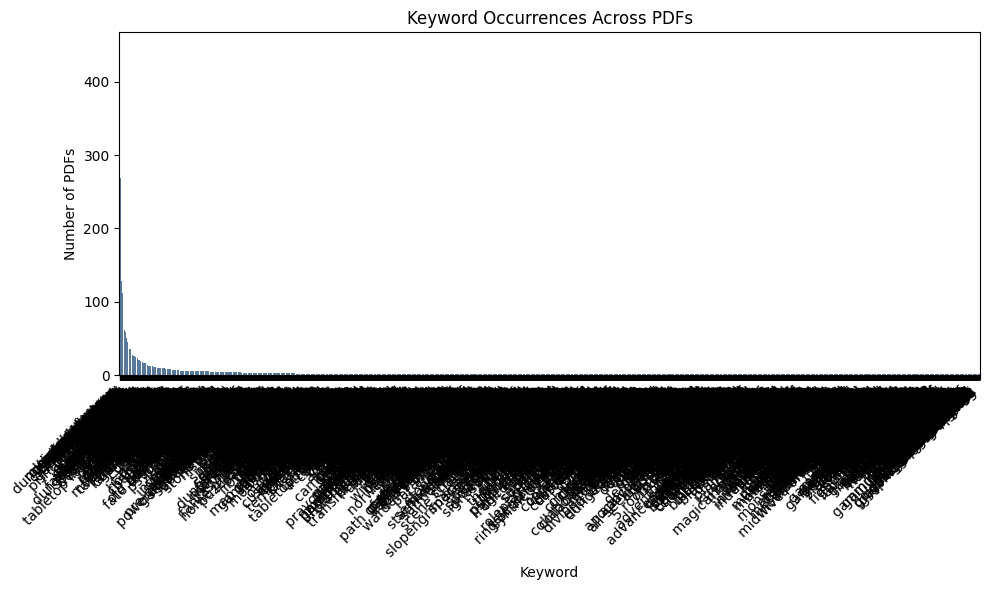

In [54]:
plot_keyword_occurrences(counts)


In [29]:
tags = list(map(lambda x: x[0], counts[["keywords"]].values))
tag_embeddings = generate_tag_embeddings(tags, lambda t: get_tag_embedding(t, model="nomic-embed-text-v2-moe"), workers=128)
tag_embeddings.head()


Embedding tags:   0%|          | 0/3782 [00:00<?, ?tag/s]

,tag,embedding
0,virtual tabletop,"[[0.037815038, 0.07242084, -0.002588359, -0.03..."
1,skills,"[[-0.039316256, -0.020267148, 0.021396298, 0.0..."
2,roleplaying game,"[[0.09051817, -0.022023913, 0.0029021641, -0.0..."
3,horror,"[[0.0016625604, -0.016163573, -0.010442871, 0...."
4,battle map,"[[-0.00019762335, 0.01859824, -0.09529039, 0.0..."


In [7]:
# results = evaluate_agglomerative_cluster_counts(tag_embeddings, range(10, 1000, 10), workers=12)
# sns.scatterplot(data=results, x="n_clusters", y="silhouette_score")


,index,tag,cluster_id
0,3429,frontier town,0
1,3556,fiend,0
2,3425,frontier,0
3,3576,ferengi,0
4,836,ferns,0
5,3596,fences,0
6,1148,dales,1
7,516,druids,1
8,224,druid,1
9,2560,duress,1


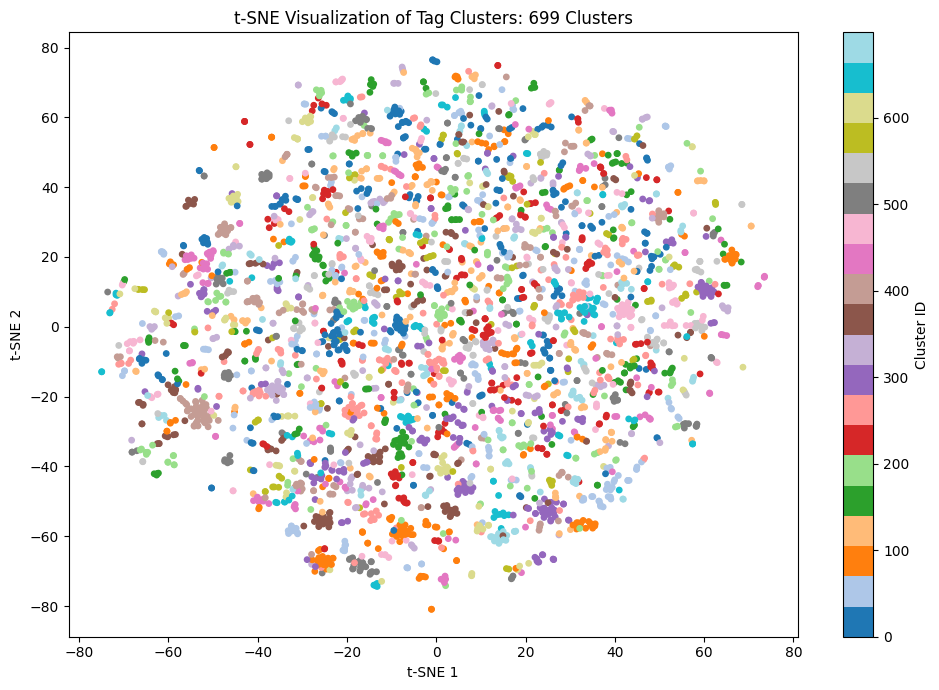

In [31]:
clusters = agglomerative_cluster_tags(tag_embeddings, n_clusters=700)

with pandas.option_context(
    "display.max_rows", 20,          # None = show all rows regardless of size
    "display.max_columns", 20,
    "display.min_rows", None           # disable head/tail truncation
):
    sorted_clusters = clusters.sort_values(by=["cluster_id"]).reset_index()
    display(sorted_clusters)

plot_tsne_clusters(tag_embeddings, clusters)


/Users/toby/.pyenv/versions/bookmeta/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,tag,cluster_id,embedding,umap_x,umap_y
0,virtual tabletop,-1,"[9.24163818359375, 6.184665679931641]",9.241638,6.184666
1,skills,18,"[12.130631446838379, 11.8834867477417]",12.130631,11.883487
2,roleplaying game,1,"[7.541044235229492, 15.606062889099121]",7.541044,15.606063
3,horror,74,"[12.493202209472656, 4.4353485107421875]",12.493202,4.435349
4,battle map,-1,"[9.959944725036621, 13.239859580993652]",9.959945,13.239860


Text(0.5, 1.0, 'Num Clusters: 150')

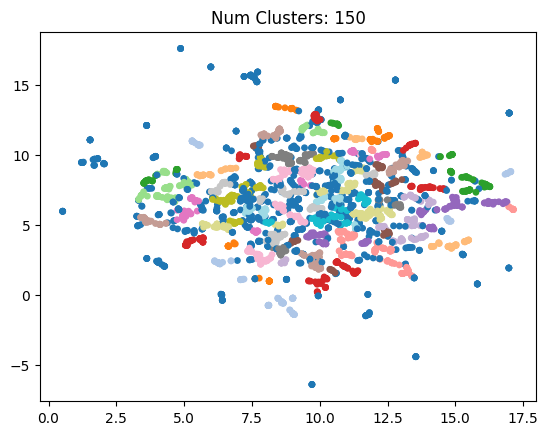

In [32]:
umap_clusters = cluster_tags_with_umap_hdbscan(tag_embeddings, min_cluster_size=4, umap_neighbors=4)
display(umap_clusters.head())
scatter = plt.scatter(umap_clusters.umap_x, umap_clusters.umap_y, c=umap_clusters.cluster_id, cmap="tab20", s=15)
plt.title(f"Num Clusters: {len(umap_clusters.cluster_id.unique())}")


In [55]:
canonical_tags = assign_canonical_tags_per_cluster(clusters, workers=4, ollama_model="qwen2.5vl:32b")
canonical_tags.head()


Canonicalizing clusters:   0%|          | 0/700 [00:00<?, ?cluster/s]

,tag,cluster_id,canonical_tag
0,virtual tabletop,56,"tabletop gaming, virtual tabletop"
1,skills,44,"abilities, skills"
2,roleplaying game,516,"roleplaying game, tabletop roleplaying"
3,horror,462,"horror, cosmic horror"
4,battle map,416,"map, gaming map"


In [58]:
# utilities moved to normalize module

,tag,cluster_id,canonical_tag,tag_list
0,virtual tabletop,56,"tabletop gaming, virtual tabletop",tabletop gaming
1,virtual tabletop,56,"tabletop gaming, virtual tabletop",virtual tabletop
2,virtual tabletop,56,"tabletop gaming, virtual tabletop",tabletop gaming
3,virtual tabletop,56,"tabletop gaming, virtual tabletop",virtual tabletop
4,skills,44,"abilities, skills",abilities


In [59]:
len(canonical_tags.tag_list.unique())

1214

In [61]:
with pandas.option_context(
    "display.max_rows", 25,          # None = show all rows regardless of size
    "display.max_columns", 20,
    "display.min_rows", None,           # disable head/tail truncation
    "display.max_colwidth", None
):
    canonical_tags["canonical_tag_cleaned"] = canonical_tags.apply(lambda r: normalize_tag(r["canonical_tag"]), axis=1)
    grouped = canonical_tags.groupby("canonical_tag_cleaned").agg({"tag": set}).sort_values(by=["canonical_tag_cleaned"]).reset_index()
    display(grouped)

print(len(grouped))


,canonical_tag_cleaned,tag
0,"1920s, 1920s era","{1920s setting, 1920s berlin, 1920s era, 1921, 1920s, 2095, 1922}"
1,"1930s, 1930s 1950s","{1931, 1935, 1935-1951}"
2,"1960s, 1970s","{1968 setting, 1970s}"
3,"19th century, istanbul","{19th century istanbul, 19th century}"
4,"5e, dungeons and dragons 5th edition","{fifth edition, 5e conversion, 5th level, 5th edition, sw5e, srd5, 5e compatible, d&d 5e, 5e}"
5,"7th sea, role playing game","{7th sea, 7th edition, 7th sea second edition}"
6,"a4, 4th edition","{4e maenad, a4, a4 printable, a4 pdf, 4e centaur, d&d 4th edition, cc by 4.0, 4th edition, a4 printing, a4 pages}"
7,"aberrant, declan l'estrange","{aberrants, declan l'estrange}"
8,"abilities, skills","{meta-talent, agility, intellect, investigative abilities, skills training, skills system, combat abilities, tool proficiencies, character abilities, skills revision, meta-talents, proficiency, investigator skills, skills, core abilities, talents, proficiencies, psionic talents, special abilities, abilities}"
9,"achievements, wonders","{wonders, discoveries, incantations, achievements}"


700


In [62]:
df

,pdf_hash,title,keywords
0,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,Blades in the Dark,"[tabletop, roleplaying, heist, crew, fantasy, ..."
1,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,Blades in the Dark,"[tabletop, roleplaying, heist, crew, fantasy, ..."
2,dcb75376f7861f97b8efe97085417d1de521df15e13a5d...,Blades in the Dark,"[game, roleplaying, fantasy, intrigue]"
3,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,Monster of the Week,"[RPG, horror, monster hunting]"
4,690ff067b8e6dd04d5fd0b4977c92b0f7d389e32123549...,Monster of the Week,"[RPG, horror, monster hunting]"
...,...,...,...
1614,27caf8026f1690f840094055593479fbab0fedde738424...,Wanderhome Traits,"[kith, traits, character types, role-playing, ..."
1615,b0d62f453acb134fce4955be903aa1b426354fb42444ca...,Wanderhome,"[pastoral, fantasy, tabletop, role-playing gam..."
1616,b48761e04e67b897021777590f7c3c007810d6b80b7007...,Worlds Without Number,"[rpg, fantasy, magic, character creation, camp..."
1617,f1c70a65ffbe730a4a2e9cb7f622e626dd214f7149db0a...,Wanderhome,"[pastoral fantasy, animal-folk, tabletop RPG, ..."


In [182]:
from src.normalize.pipeline import normalize_keywords_pipeline


df = normalize_keywords_pipeline(
        db_path="../resources/bookmeta.db",
        workers=12,
        embedding_host="http://192.168.1.31:11434",
        embedding_model="snowflake-arctic-embed:335m",
        cluster_count=750,
        canonical_host="http://192.168.1.31:11434",
        canonical_model="qwen2.5vl:32b",
        canonical_temperature=0.05,
    )

ModuleNotFoundError: No module named 'storage'